In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

In [3]:
start_date = '2010-01-02'
end_date = '2025-12-31'
dat = yf.download('JPM', start = start_date, end = end_date, interval = '1d')

[*********************100%***********************]  1 of 1 completed


In [4]:
dat

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2010-01-04,28.279198,28.371594,27.500447,27.579644,35460500
2010-01-05,28.826979,28.932572,28.233015,28.239616,41208300
2010-01-06,28.985344,29.097538,28.582772,28.675165,27729000
2010-01-07,29.559519,29.777304,28.780768,28.899561,44864700
2010-01-08,29.486929,29.500128,29.090955,29.282341,33110100
...,...,...,...,...,...
2025-12-23,322.814331,324.646652,320.001483,320.516501,6668300
2025-12-24,326.023376,326.835515,322.388446,323.121362,4289300


In [5]:
dat['p'] = dat['Close'].diff().dropna()
dat['r'] = dat['Close'] / dat['Close'].shift(1)
dat = dat.dropna()

In [6]:
df_train = dat[:'2021-12-31']
df_valid = dat['2022-01-01':'2023-12-31']
df_test = dat['2024-01-01':]
dat_r = dat['r']
dat_p = dat['p']

In [7]:
train_r = df_train['r']
valid_r = df_valid['r']
test_r = df_test['r']
train_p = df_train['p']
valid_p = df_valid['p']
test_p = df_test['p']

Model 1 - Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [9]:
def create_features_rf(series, lookback):
    """
    Build a supervised learning dataset from a time series.
    X[i] = [series[i], series[i+1], ..., series[i+lookback-1]]
    Y[i] = series[i+lookback]
    """
    X, Y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i : i + lookback])
        Y.append(series[i + lookback])
    return np.array(X), np.array(Y)

In [10]:
lookback_list_rf = [3, 5, 10]
n_estimators_list = [100, 200]
max_depth_list = [3, 5, None]

best_rf_params  = {}
best_rf_rmse    = np.inf

for lookback in lookback_list_rf:
    valid_p_ext = pd.concat([train_p.iloc[-lookback:], valid_p])
    X_train, Y_train = create_features_rf(train_p.values.squeeze(), lookback)
    X_valid, Y_valid = create_features_rf(valid_p_ext.values.squeeze(), lookback)

    for n_est in n_estimators_list:
        for max_d in max_depth_list:
            rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_d,
                                       random_state=42, n_jobs=-1)
            rf.fit(X_train, Y_train)
            y_pred_valid = rf.predict(X_valid)
            rmse_v = np.sqrt(mean_squared_error(Y_valid, y_pred_valid))
            if rmse_v < best_rf_rmse:
                best_rf_rmse = rmse_v
                best_rf_params = {'lookback': lookback, 'n_estimators': n_est, 'max_depth': max_d}
                best_rf_model  = rf
            print(f"lookback={lookback}, n_est={n_est}, max_depth={max_d}  →  valid RMSE={rmse_v:.4f}")

print("\nBest RF params:", best_rf_params)
print(f"Best valid RMSE: {best_rf_rmse:.4f}")

lookback=3, n_est=100, max_depth=3  →  valid RMSE=2.0101
lookback=3, n_est=100, max_depth=5  →  valid RMSE=2.0391
lookback=3, n_est=100, max_depth=None  →  valid RMSE=2.1093
lookback=3, n_est=200, max_depth=3  →  valid RMSE=2.0093
lookback=3, n_est=200, max_depth=5  →  valid RMSE=2.0385
lookback=3, n_est=200, max_depth=None  →  valid RMSE=2.1089
lookback=5, n_est=100, max_depth=3  →  valid RMSE=1.9871
lookback=5, n_est=100, max_depth=5  →  valid RMSE=2.0129
lookback=5, n_est=100, max_depth=None  →  valid RMSE=2.0606
lookback=5, n_est=200, max_depth=3  →  valid RMSE=1.9950
lookback=5, n_est=200, max_depth=5  →  valid RMSE=2.0198
lookback=5, n_est=200, max_depth=None  →  valid RMSE=2.0665
lookback=10, n_est=100, max_depth=3  →  valid RMSE=1.9787
lookback=10, n_est=100, max_depth=5  →  valid RMSE=1.9952
lookback=10, n_est=100, max_depth=None  →  valid RMSE=2.0497
lookback=10, n_est=200, max_depth=3  →  valid RMSE=1.9803
lookback=10, n_est=200, max_depth=5  →  valid RMSE=1.9990
lookback=10

In [12]:
lb = best_rf_params['lookback']
test_p_ext = pd.concat([valid_p.iloc[-lb:], test_p])
X_test_rf, Y_test_rf = create_features_rf(test_p_ext.values.squeeze(), lb)

y_pred_rf = best_rf_model.predict(X_test_rf)

p_current_rf = dat['Close'].loc[test_p_ext.index[lb - 1 : len(test_p_ext) - 1]]
p_next_rf    = dat['Close'].loc[test_p_ext.index[lb :]]
p_forecast_rf = p_current_rf.values.squeeze() + y_pred_rf

rmse_rf = np.sqrt(np.mean((p_next_rf.values.squeeze() - p_forecast_rf) ** 2))
print(f"RF Test RMSE (price): {rmse_rf:.4f}")

RF Test RMSE (price): 3.6253


In [16]:
results = pd.DataFrame({
    'True_price_change': Y_test_rf.flatten(),
    'Pred_price_change': y_pred_rf.flatten(),
    'True_price':        p_next_rf.values.squeeze(),
    'Pred_price':        p_forecast_rf
}, index=p_next_rf.index)

In [17]:
results

,True_price_change,Pred_price_change,True_price,Pred_price
Date,,,,
2024-01-02,1.875656,0.042511,163.009369,161.176224
2024-01-03,-0.710480,0.048895,162.298889,163.058264
2024-01-04,1.077026,0.042511,163.375916,162.341400
2024-01-05,0.819702,0.042511,164.195618,163.418426
2024-01-08,-0.238312,0.042511,163.957306,164.238128
...,...,...,...,...
2025-12-23,2.812866,0.211961,322.814331,320.213426
2025-12-24,3.209045,-0.061784,326.023376,322.752547
2025-12-26,-1.247955,-0.274073,324.775421,325.749303


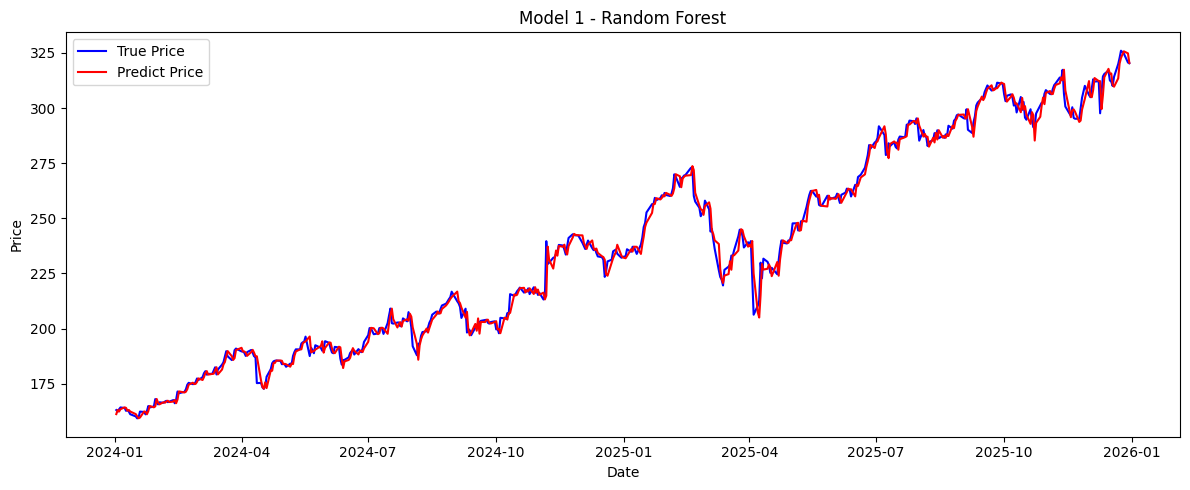

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(p_next_rf.index, p_next_rf.values.squeeze(), color = 'blue', label='True Price', linewidth=1.5)
plt.plot(p_next_rf.index, p_forecast_rf, color = 'red', label='Predict Price', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model 1 - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

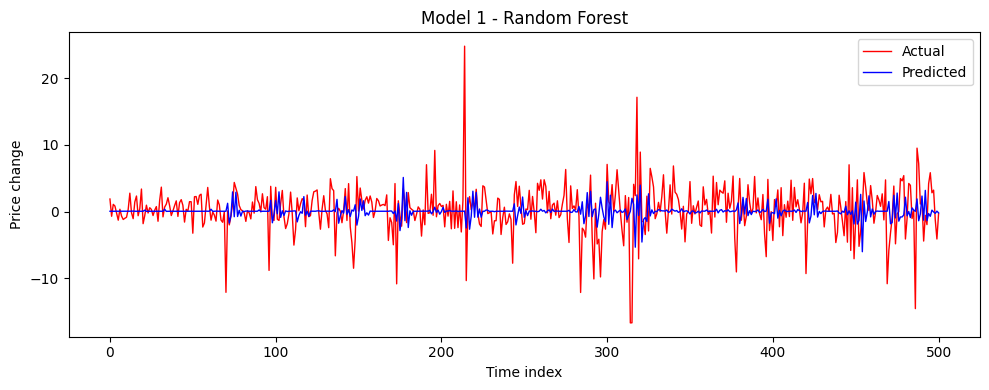

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))

price_change_true = Y_test_rf.flatten()           
price_change_pred = y_pred_rf.flatten()  

ax.plot(price_change_true, color='red',  label='Actual',    linewidth=1)
ax.plot(price_change_pred, color='blue', label='Predicted',  linewidth=1)
ax.set_xlabel('Time index')
ax.set_ylabel('Price change')
ax.set_title('Model 1 - Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

Model 2 - XGBoost

In [24]:
!pip install xgboost -q
from xgboost import XGBRegressor

In [25]:
lookback_list_xgb  = [3, 5, 10]
n_estimators_xgb   = [100, 200]
max_depth_xgb      = [3, 5, 7]
learning_rate_xgb  = [0.05, 0.1]

best_xgb_params = {}
best_xgb_rmse   = np.inf

for lookback in lookback_list_xgb:
    valid_p_ext = pd.concat([train_p.iloc[-lookback:], valid_p])
    X_train, Y_train = create_features_rf(train_p.values.squeeze(), lookback)
    X_valid, Y_valid = create_features_rf(valid_p_ext.values.squeeze(), lookback)

    for n_est in n_estimators_xgb:
        for max_d in max_depth_xgb:
            for lr in learning_rate_xgb:
                xgb = XGBRegressor(n_estimators=n_est, max_depth=max_d,
                                   learning_rate=lr, random_state=42,
                                   verbosity=0, n_jobs=-1)
                xgb.fit(X_train, Y_train)
                y_pred_valid_xgb = xgb.predict(X_valid)
                rmse_v = np.sqrt(mean_squared_error(Y_valid, y_pred_valid_xgb))
                if rmse_v < best_xgb_rmse:
                    best_xgb_rmse   = rmse_v
                    best_xgb_params = {'lookback': lookback, 'n_estimators': n_est,
                                       'max_depth': max_d, 'learning_rate': lr}
                    best_xgb_model  = xgb
                print(f"lb={lookback}, n_est={n_est}, depth={max_d}, lr={lr}  →  valid RMSE={rmse_v:.4f}")

print("\nBest XGB params:", best_xgb_params)
print(f"Best valid RMSE: {best_xgb_rmse:.4f}")

lb=3, n_est=100, depth=3, lr=0.05  →  valid RMSE=2.0226
lb=3, n_est=100, depth=3, lr=0.1  →  valid RMSE=2.0494
lb=3, n_est=100, depth=5, lr=0.05  →  valid RMSE=2.0910
lb=3, n_est=100, depth=5, lr=0.1  →  valid RMSE=2.1677
lb=3, n_est=100, depth=7, lr=0.05  →  valid RMSE=2.1858
lb=3, n_est=100, depth=7, lr=0.1  →  valid RMSE=2.1863
lb=3, n_est=200, depth=3, lr=0.05  →  valid RMSE=2.0473
lb=3, n_est=200, depth=3, lr=0.1  →  valid RMSE=2.1195
lb=3, n_est=200, depth=5, lr=0.05  →  valid RMSE=2.1476
lb=3, n_est=200, depth=5, lr=0.1  →  valid RMSE=2.2119
lb=3, n_est=200, depth=7, lr=0.05  →  valid RMSE=2.2286
lb=3, n_est=200, depth=7, lr=0.1  →  valid RMSE=2.2163
lb=5, n_est=100, depth=3, lr=0.05  →  valid RMSE=2.0468
lb=5, n_est=100, depth=3, lr=0.1  →  valid RMSE=2.0828
lb=5, n_est=100, depth=5, lr=0.05  →  valid RMSE=2.1062
lb=5, n_est=100, depth=5, lr=0.1  →  valid RMSE=2.1287
lb=5, n_est=100, depth=7, lr=0.05  →  valid RMSE=2.1040
lb=5, n_est=100, depth=7, lr=0.1  →  valid RMSE=2.1393
l

In [ ]:
lb = best_rf_params['lookback']
test_p_ext = pd.concat([valid_p.iloc[-lb:], test_p])
X_test_rf, Y_test_rf = create_features_rf(test_p_ext.values.squeeze(), lb)

y_pred_rf = best_rf_model.predict(X_test_rf)

p_current_rf = dat['Close'].loc[test_p_ext.index[lb - 1 : len(test_p_ext) - 1]]
p_next_rf    = dat['Close'].loc[test_p_ext.index[lb :]]
p_forecast_rf = p_current_rf.values.squeeze() + y_pred_rf

rmse_rf = np.sqrt(np.mean((p_next_rf.values.squeeze() - p_forecast_rf) ** 2))
print(f"RF Test RMSE (price): {rmse_rf:.4f}")

In [ ]:
results = pd.DataFrame({
    'True_price_change': Y_test_rf.flatten(),
    'Pred_price_change': y_pred_rf.flatten(),
    'True_price':        p_next_rf.values.squeeze(),
    'Pred_price':        p_forecast_rf
}, index=p_next_rf.index)

In [ ]:
results

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(p_next_rf.index, p_next_rf.values.squeeze(), color = 'blue', label='True Price', linewidth=1.5)
plt.plot(p_next_rf.index, p_forecast_rf, color = 'red', label='Predict Price', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model 1 - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

price_change_true = Y_test_rf.flatten()           
price_change_pred = y_pred_rf.flatten()  

ax.plot(price_change_true, color='red',  label='Actual',    linewidth=1)
ax.plot(price_change_pred, color='blue', label='Predicted',  linewidth=1)
ax.set_xlabel('Time index')
ax.set_ylabel('Price change')
ax.set_title('Model 1 - Random Forest')
ax.legend()
plt.tight_layout()
plt.show()